# Phase 1 - Heart Disease Prediction

**Course:** SWE485 (Selected Topics in Software Engineering)  
**Phase:** 1 (Problem Understanding & Data Exploration)  
**Dataset:** Heart Disease Dataset (Kaggle)

This notebook covers:
-  Introduction  
-  Problem Definition  
-  Dataset Selection and Justification  
-  Initial Data Inspection  
-  Exploratory Data Analysis (EDA)  
-  Data Preprocessing  
-  Preprocessed Dataset Ready for Modeling  
-  Key Insights and Challenges



## Introduction

Heart disease is one of the leading causes of death worldwide. Early detection and prediction of heart disease can significantly improve treatment outcomes and help healthcare providers take preventive actions. With the increasing availability of healthcare data, machine learning techniques can be used to analyze patient health information and identify patterns related to disease risk.

The goal of this project is to develop a **Heart Disease Prediction System** using machine learning techniques. The system analyzes patient health attributes such as age, blood pressure, cholesterol level, chest pain type, and other clinical measurements to predict whether a patient is likely to have heart disease.

This project follows a typical machine learning pipeline that includes **data exploration, preprocessing, model training, and evaluation**. In Phase 1, the focus is on understanding the dataset, performing exploratory data analysis (EDA), preparing the data for modeling, and building supervised learning models for prediction.



## Problem Definition

Heart disease is a major global health concern and remains one of the most common causes of death. Diagnosing heart disease often requires multiple medical tests and expert analysis, which may not always be easily accessible or affordable for all individuals.

The problem addressed in this project is to **predict whether a patient has heart disease based on clinical and medical attributes**. By analyzing patient data using machine learning algorithms, the system aims to classify individuals into two categories: **presence or absence of heart disease**.

Developing such a prediction system can assist healthcare professionals by providing an additional decision-support tool for early risk assessment and potential diagnosis.


## Dataset Selection and Justification

For this project, the **Cleveland Heart Disease Dataset** was selected as the primary dataset for developing the heart disease prediction system. This dataset contains clinical and medical attributes collected from patients undergoing heart disease diagnosis. The features include several health indicators such as age, sex, chest pain type, resting blood pressure, cholesterol level, fasting blood sugar, maximum heart rate achieved, and other diagnostic measurements.

This dataset was chosen because it is highly relevant to the problem of heart disease prediction. The available features represent important medical factors that are commonly used by healthcare professionals when assessing cardiovascular risk. In addition, the dataset is structured and well-documented, which makes it suitable for machine learning analysis and preprocessing.

The dataset also supports a **classification task**, where the target variable indicates whether a patient has heart disease or not. This makes it appropriate for applying supervised machine learning algorithms to build a predictive model. Furthermore, the dataset has been widely used in machine learning research, making it a reliable and commonly accepted benchmark for heart disease prediction studies.

The dataset used in this project is publicly available and can be accessed from the following source:

https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci

In [325]:
# import data science basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import warnings
import math

warnings.filterwarnings('ignore')

## **1. Exploratory Data Analysis**
To better understand the dataset and identify important patterns, exploratory data analysis (EDA) is performed. EDA helps analyze the distribution of features, detect potential correlations between variables, and understand the relationship between patient attributes and the presence of heart disease.

During this stage, several statistical summaries and visualizations are generated to explore the dataset. These include feature distributions, correlation analysis, and class distribution plots. The goal of this analysis is to gain insights into the data and determine which features may be most relevant for predicting heart disease.

The following sections present the detailed exploration of the dataset, including data inspection, visualization, and preprocessing steps that prepare the data for machine learning models.


## Dataset Attributes

#### Age
**Definition:**  
Age represents the patient’s age measured in years.

**Medical Explanation:**  
Age is one of the strongest predictors of cardiovascular disease. As individuals age, structural and functional changes occur in the cardiovascular system. These changes include arterial stiffening, endothelial dysfunction, and the progressive accumulation of atherosclerotic plaque in coronary arteries.

**Relation to Heart Disease:**  
Increasing age is strongly associated with a higher probability of developing coronary artery disease. Therefore, age is considered an important predictive feature in heart disease classification models.

---

#### Sex
**Definition:**  
Sex indicates the biological sex of the patient.

Values:
- M: Male  
- F: Female

**Medical Explanation:**  
Sex differences play a significant role in cardiovascular disease risk. Men generally develop coronary artery disease earlier than women. In women, estrogen provides protective cardiovascular effects before menopause by improving lipid metabolism and vascular function.

**Relation to Heart Disease:**  
Males typically show a higher prevalence of heart disease at younger ages, while female risk increases after menopause. Therefore, sex is an important demographic feature when predicting heart disease.

---

#### ChestPainType
**Definition:**  
ChestPainType describes the type of chest pain experienced by the patient.

Values:
- TA: Typical Angina  
- ATA: Atypical Angina  
- NAP: Non-Anginal Pain  
- ASY: Asymptomatic

**Medical Explanation:**  

**Typical Angina (TA):**  
Classic chest pain caused by myocardial ischemia. It usually occurs during physical exertion or emotional stress and is relieved by rest or nitroglycerin.

**Atypical Angina (ATA):**  
Chest pain that does not fully meet the criteria for typical angina but may still indicate underlying coronary artery disease.

**Non-Anginal Pain (NAP):**  
Chest pain that is not related to myocardial ischemia and may originate from gastrointestinal, pulmonary, or musculoskeletal causes.

**Asymptomatic (ASY):**  
Patients who do not experience chest pain despite possible underlying cardiac disease.

**Relation to Heart Disease:**  
Typical and atypical angina are strongly associated with coronary artery disease, while non-anginal pain is less likely to indicate heart disease. This feature is therefore clinically relevant for predicting heart disease.

---

#### RestingBP
**Definition:**  
RestingBP refers to the resting systolic blood pressure measured in millimeters of mercury (mmHg).

**Medical Explanation:**  
Blood pressure represents the force exerted by circulating blood against arterial walls. Chronic hypertension damages blood vessels, accelerates atherosclerosis, and increases cardiac workload.

**Relation to Heart Disease:**  
Elevated resting blood pressure is a major risk factor for cardiovascular diseases, including coronary artery disease, heart failure, and stroke. Therefore, higher resting blood pressure values may increase the likelihood of heart disease.

---

#### Cholesterol
**Definition:**  
Cholesterol represents the serum cholesterol level measured in milligrams per deciliter (mg/dl).

**Medical Explanation:**  
Cholesterol is a lipid molecule necessary for various biological processes. However, excessive cholesterol, particularly low-density lipoprotein (LDL), contributes to the formation of atherosclerotic plaques within coronary arteries.

**Relation to Heart Disease:**  
High cholesterol levels are strongly associated with coronary artery disease because plaque accumulation can narrow arteries and restrict blood flow to the heart. Thus, cholesterol level is an important predictor of heart disease.

---

#### FastingBS
**Definition:**  
FastingBS indicates whether the patient’s fasting blood sugar exceeds 120 mg/dl.

Values:
- 1: Fasting blood sugar > 120 mg/dl  
- 0: Fasting blood sugar ≤ 120 mg/dl

**Medical Explanation:**  
Fasting blood glucose measures blood sugar levels after a period of fasting. Elevated levels are commonly associated with diabetes mellitus.

**Relation to Heart Disease:**  
Diabetes significantly increases cardiovascular risk by promoting endothelial damage, inflammation, and accelerated atherosclerosis. Therefore, patients with high fasting blood sugar are more likely to develop heart disease.

---

#### RestingECG
**Definition:**  
RestingECG represents the result of the resting electrocardiogram test.

Values:
- Normal: Normal ECG result  
- ST: ST-T wave abnormality  
- LVH: Left ventricular hypertrophy

**Medical Explanation:**  
An electrocardiogram records the electrical activity of the heart.

**Normal:**  
Indicates normal electrical activity with no detectable abnormalities.

**ST-T Abnormality:**  
Represents abnormalities in the ST segment or T wave, which may indicate myocardial ischemia or electrolyte imbalance.

**Left Ventricular Hypertrophy (LVH):**  
Indicates thickening of the left ventricular wall, often caused by chronic hypertension or heart disease.

**Relation to Heart Disease:**  
Abnormal ECG patterns such as ST-T changes or LVH can indicate underlying cardiac abnormalities or structural heart disease. Therefore, this attribute is useful in heart disease prediction.

---

#### MaxHR
**Definition:**  
MaxHR represents the maximum heart rate achieved during an exercise stress test.

**Medical Explanation:**  
The exercise stress test evaluates cardiovascular performance under physical exertion. Maximum heart rate reflects the heart’s ability to respond to increased oxygen demand during exercise.

**Relation to Heart Disease:**  
Patients with coronary artery disease may fail to achieve normal maximum heart rates due to impaired cardiac function or reduced blood supply to the myocardium. Thus, abnormal MaxHR values may indicate heart disease.

---

#### ExerciseAngina
**Definition:**  
ExerciseAngina indicates whether the patient experiences angina during physical exercise.

Values:
- Y: Yes  
- N: No

**Medical Explanation:**  
Exercise-induced angina occurs when the heart muscle requires more oxygen during exertion than can be supplied through narrowed coronary arteries.

**Relation to Heart Disease:**  
The presence of exercise-induced angina strongly suggests myocardial ischemia and is therefore an important indicator of coronary artery disease.

---

#### Oldpeak
**Definition:**  
Oldpeak represents the ST-segment depression observed during an exercise stress test compared with the resting ECG.

**Medical Explanation:**  
ST-segment depression is a key electrocardiographic indicator used during stress testing to detect myocardial ischemia. The value represents the magnitude of ST depression measured in millivolts.

**Relation to Heart Disease:**  
Higher Oldpeak values indicate greater ST depression during exercise, which is strongly associated with reduced coronary blood flow and the presence of coronary artery disease.

---

#### ST_Slope
**Definition:**  
ST_Slope represents the slope of the ST segment during peak exercise.

Values:
- Up: Upsloping  
- Flat: Flat  
- Down: Downsloping

**Medical Explanation:**  
The slope of the ST segment during exercise provides information about myocardial oxygen supply and demand.

**Upsloping:**  
Generally considered a normal response during exercise.

**Flat:**  
May indicate myocardial ischemia.

**Downsloping:**  
Strongly associated with significant coronary artery disease.

**Relation to Heart Disease:**  
Flat or downsloping ST segments are commonly observed in patients with coronary artery disease, making this feature important for classification.

---

#### HeartDisease (Target Variable)
**Definition:**  
HeartDisease represents the target variable used in the classification model.

Values:
- 1: Presence of heart disease  
- 0: No heart disease

**Medical Explanation:**  
This variable indicates whether the patient has been diagnosed with heart disease based on clinical evaluation and diagnostic tests.

**Relation to Heart Disease:**  
This is the **output variable** that the machine learning model attempts to predict using the other attributes as predictive features.

---

#### References

1. UCI Machine Learning Repository. Heart Disease Dataset.  
   https://archive.ics.uci.edu/dataset/45/heart+disease

2. Detrano, R. et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology.

3. Braunwald, E. (2019). Braunwald's Heart Disease: A Textbook of Cardiovascular Medicine. Elsevier.

4. Ahmad, Z., et al. (2023). Prediction of Heart Disease Based on Machine Learning Techniques. PMC.

5. Gibbons, R. J., et al. (2002). ACC/AHA Guidelines for Exercise Testing. Journal of the American College of Cardiology.

### 1.1 Initial Data Inspection

In [326]:
# load data
DATA_PATH='Dataset/heart.csv'

df = pd.read_csv(DATA_PATH)

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [327]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

### 1.2 Features Descriptive Statistics

In [328]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 1.3 Missing Values

In [329]:
missing_per_col = df.isnull().sum().sort_values(ascending=False)
total_missing = int(missing_per_col.sum())

display(missing_per_col.to_frame("missing_count").head(20))

,missing_count
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


### 1.4 Duplicate Records

In [330]:
df[df.duplicated()]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


## **2. Visualization**

### 2.1 Targeted Class Distribution (Pie Chart)

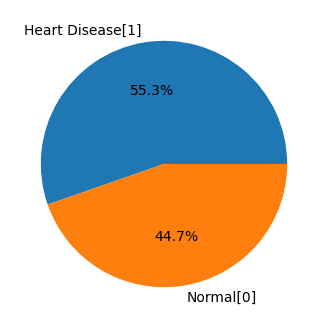

In [331]:
plt.figure(figsize=(5,4))
plt.pie(df['HeartDisease'].value_counts(), labels=['Heart Disease[1]', 'Normal[0]'], autopct='%1.1f%%')
plt.show()

### 2.2 Categorical Features (Pie chart)

Categorical variables were visualized using pie charts to examine the distribution of patients with and without heart disease for each category. These visualizations help illustrate how the proportion of heart disease cases differs across the categories of each feature, allowing for a clearer understanding of potential relationships between categorical attributes and the target variable.

Features analyzed in this section include:

* Sex
* ChestPainType
* RestingECG
* ExerciseAngina
* ST_Slope
* FastingBS


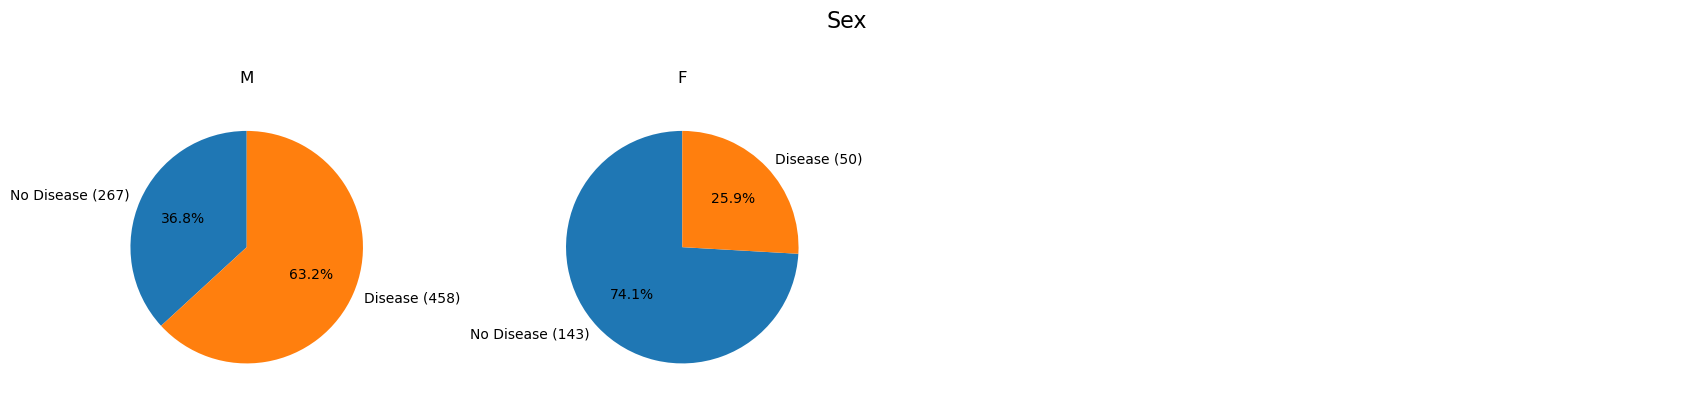


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



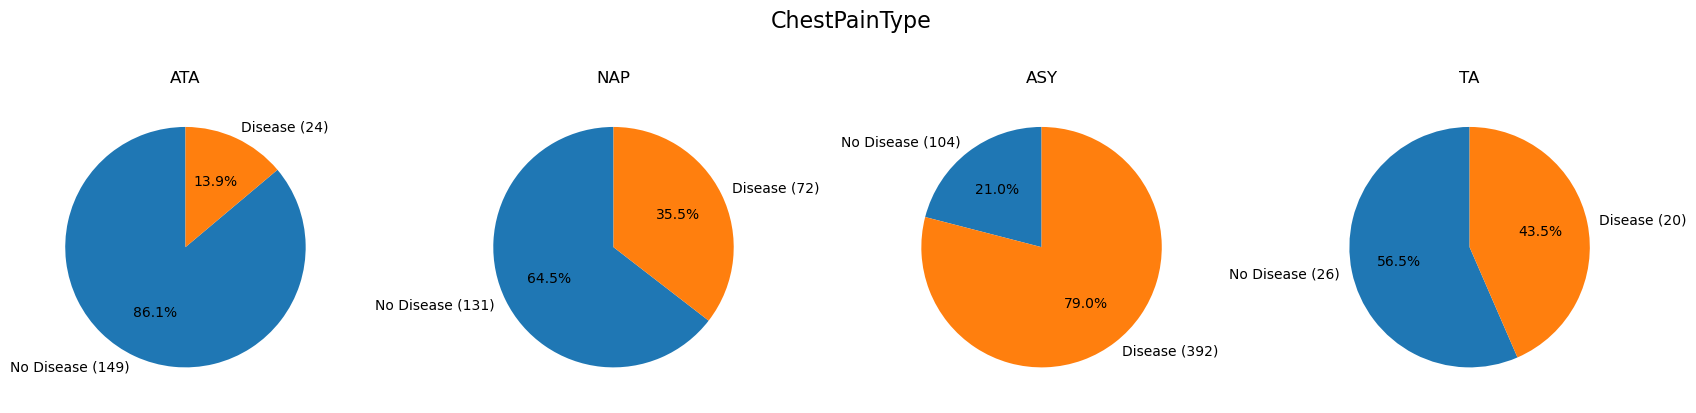


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



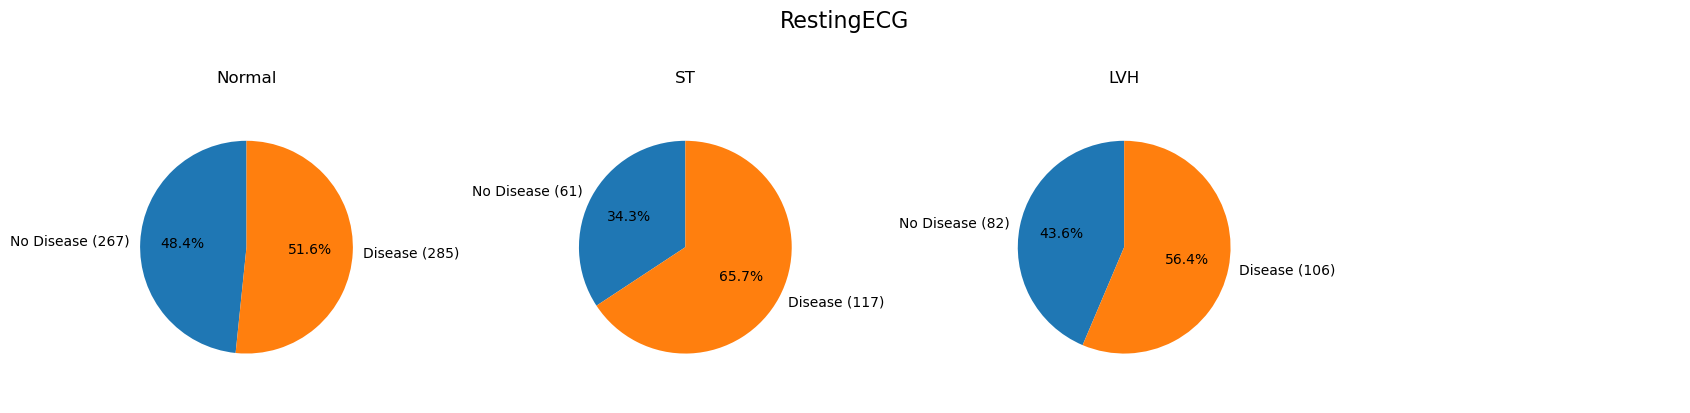


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



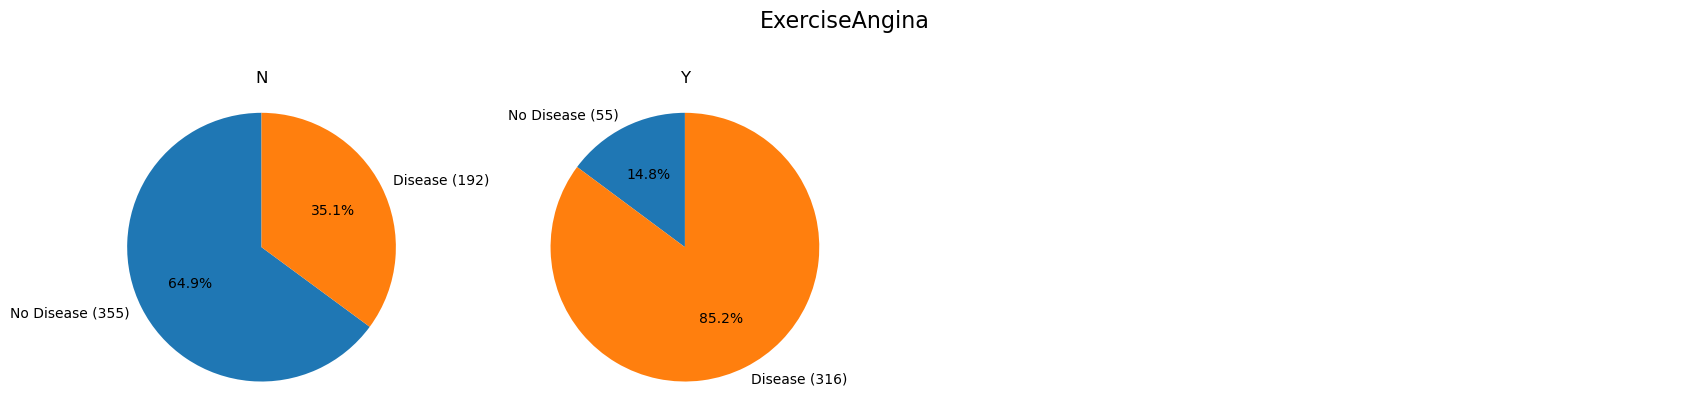


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



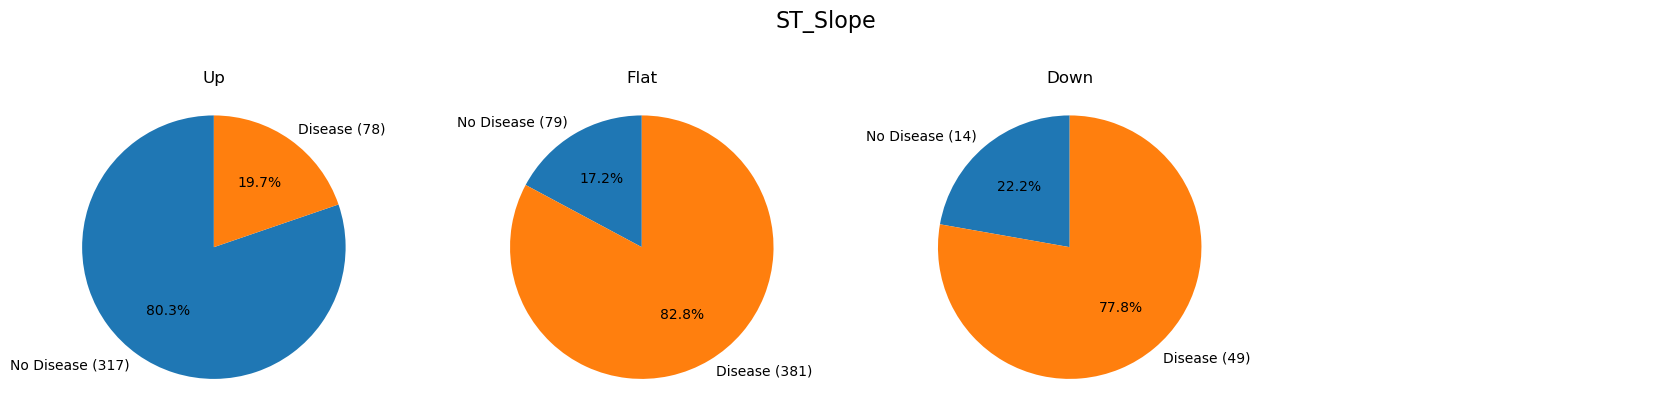


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



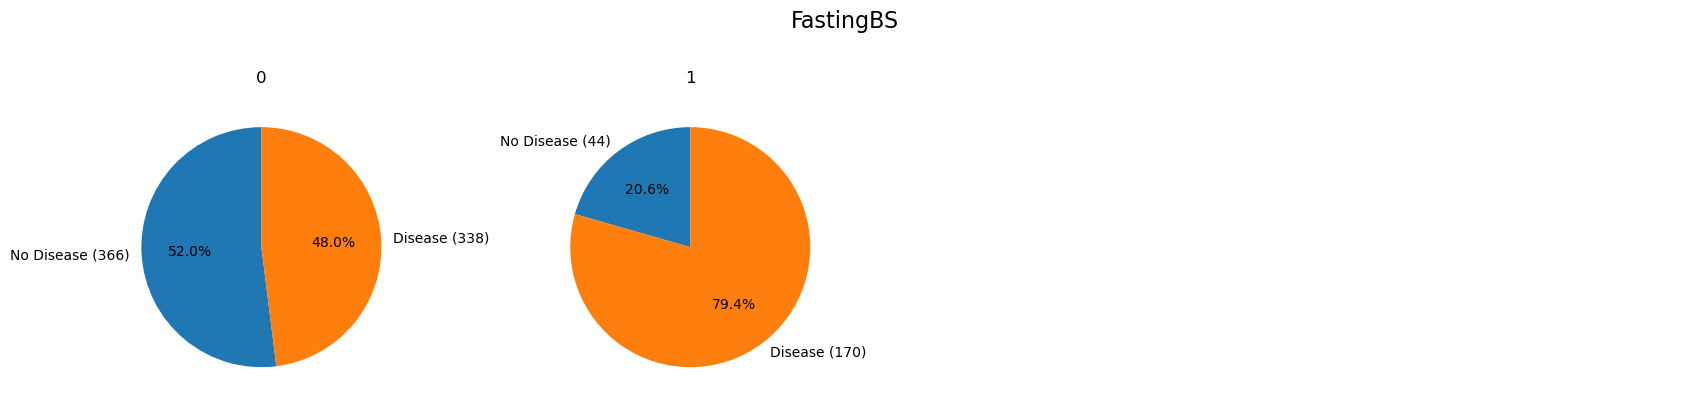


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



In [332]:
categorical_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope','FastingBS']

for col in categorical_cols:
    categories = df[col].dropna().unique()
    n = len(categories)

    ncols = 4
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4 * nrows))
    axes = axes.flatten()

    for i, cat in enumerate(categories):
        subset = df[df[col] == cat]['HeartDisease'].value_counts().sort_index()

        labels = [
            f'No Disease ({subset.get(0, 0)})',
            f'Disease ({subset.get(1, 0)})'
        ]

        values = [subset.get(0, 0), subset.get(1, 0)]

        axes[i].pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
        axes[i].set_title(f'{cat}')
        axes[i].axis('equal')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{col}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n" + "-" * 200 + "\n")

### 2.3 Numerical Features

Numerical continues variables were analyzed using histograms and boxplots to examine their distributions and detect potential differences between patients with and without heart disease.
Features analyzed include:

* Age
* RestingBP
* Cholesterol
* MaxHR
* Oldpeak


#### 2.3.1 Feature Distributions (Histograms)

Histograms were used to examine the distribution and frequency of continuous variables in order to understand their shape and detect potential skewness.

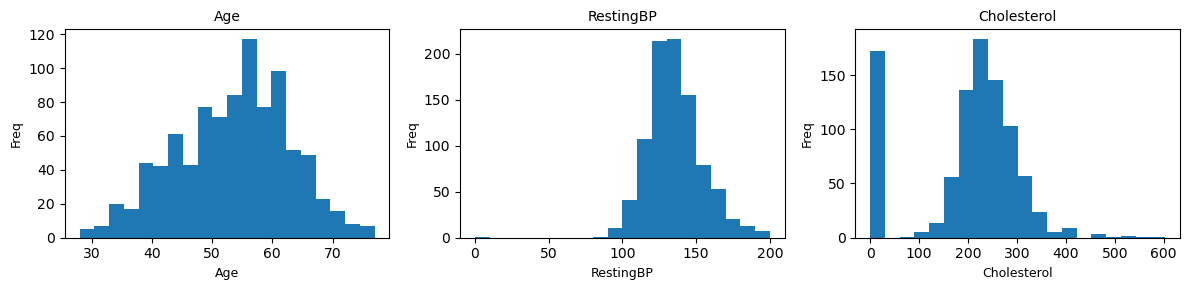

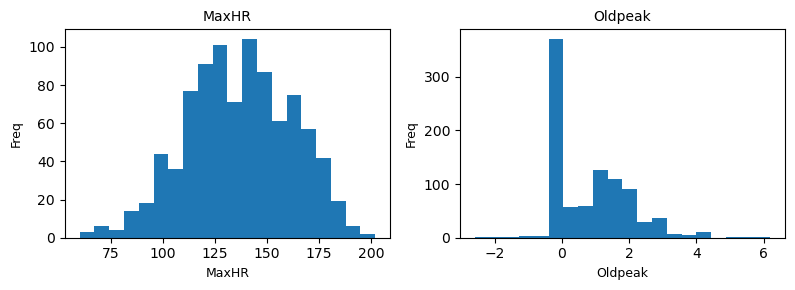

In [333]:

numeric_feature_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for i in range(0, len(numeric_feature_cols), 3):
    cols_subset = numeric_feature_cols[i:i+3]
    
    plt.figure(figsize=(12,3))
    
    for j, col in enumerate(cols_subset, 1):
        plt.subplot(1,3,j)
        plt.hist(df[col].dropna(), bins=20)
        plt.title(col, fontsize=10)
        plt.xlabel(col, fontsize=9)
        plt.ylabel("Freq", fontsize=9)
    
    plt.tight_layout()
    plt.show()

##### Histogram interpretation 

|Feature|Interpretation|
|:--:|:--:|
|Age|It shows an approximately symmetric distribution.|
|RestingBP|It shows a slightly right-skewed distribution.The slight skew may be caused by a few high-value outliers, while the main distribution appears approximately symmetric.|
|Cholesterol|It shows an approximately symmetric distribution, but with several outliers on the right side and repeated zero-value outliers on the left. These outliers may slightly affect the distribution and make it slightly skewed.|
|MaxHR| It shows an approximately symmetric distribution.|
|Oldpeak|It shows a right-skewed distribution, with few outliers on the left and several ones on the right. It also shows a repeated zero-value.|


#### 2.3.2 Outliers & Spreads (Box Plots)

box plots were used to examine the spread of the data and identify potential outliers.

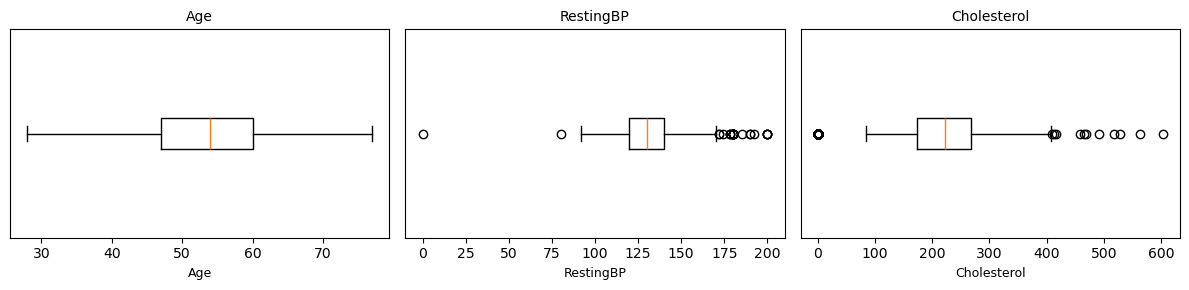

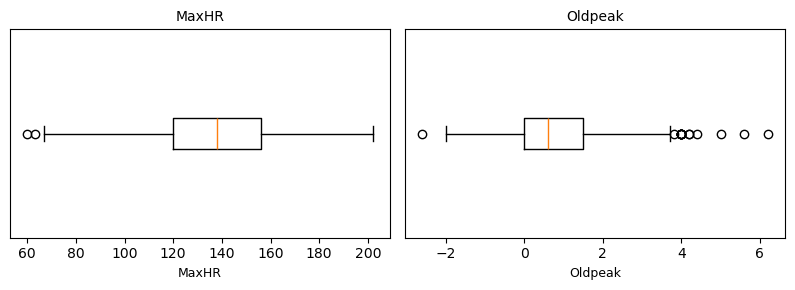

In [334]:
# select numeric columns except the target
numeric_feature_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for i in range(0, len(numeric_feature_cols), 3):
    cols_subset = numeric_feature_cols[i:i+3]
    
    plt.figure(figsize=(12,3))
    
    for j, col in enumerate(cols_subset, 1):
        plt.subplot(1,3,j)
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(col, fontsize=10)
        plt.xlabel(col, fontsize=9)
        plt.yticks([])
    
    plt.tight_layout()
    plt.show()

#### Box plots interpretation



Feature|Interpretation|
|:--:|:--:|
|Age| There is no outliers.|
|RestingBP|There are many high-value outliers on the right side, while a very low value appears on the left side.|
|Cholesterol|There are many outliers in the right and some in the left side at zero.|
|MaxHR|There are only few outliers on the left.|
|Oldpeak|There are many outliers on the right, and only few left outliers.  |

### 2.4 Features Correlation (Pair Plot)

A pair plot was used to visualize pairwise relationships between numerical variables while distinguishing observations based on the HeartDisease target variable. This helps identify potential patterns, correlations, and class separations within the dataset.

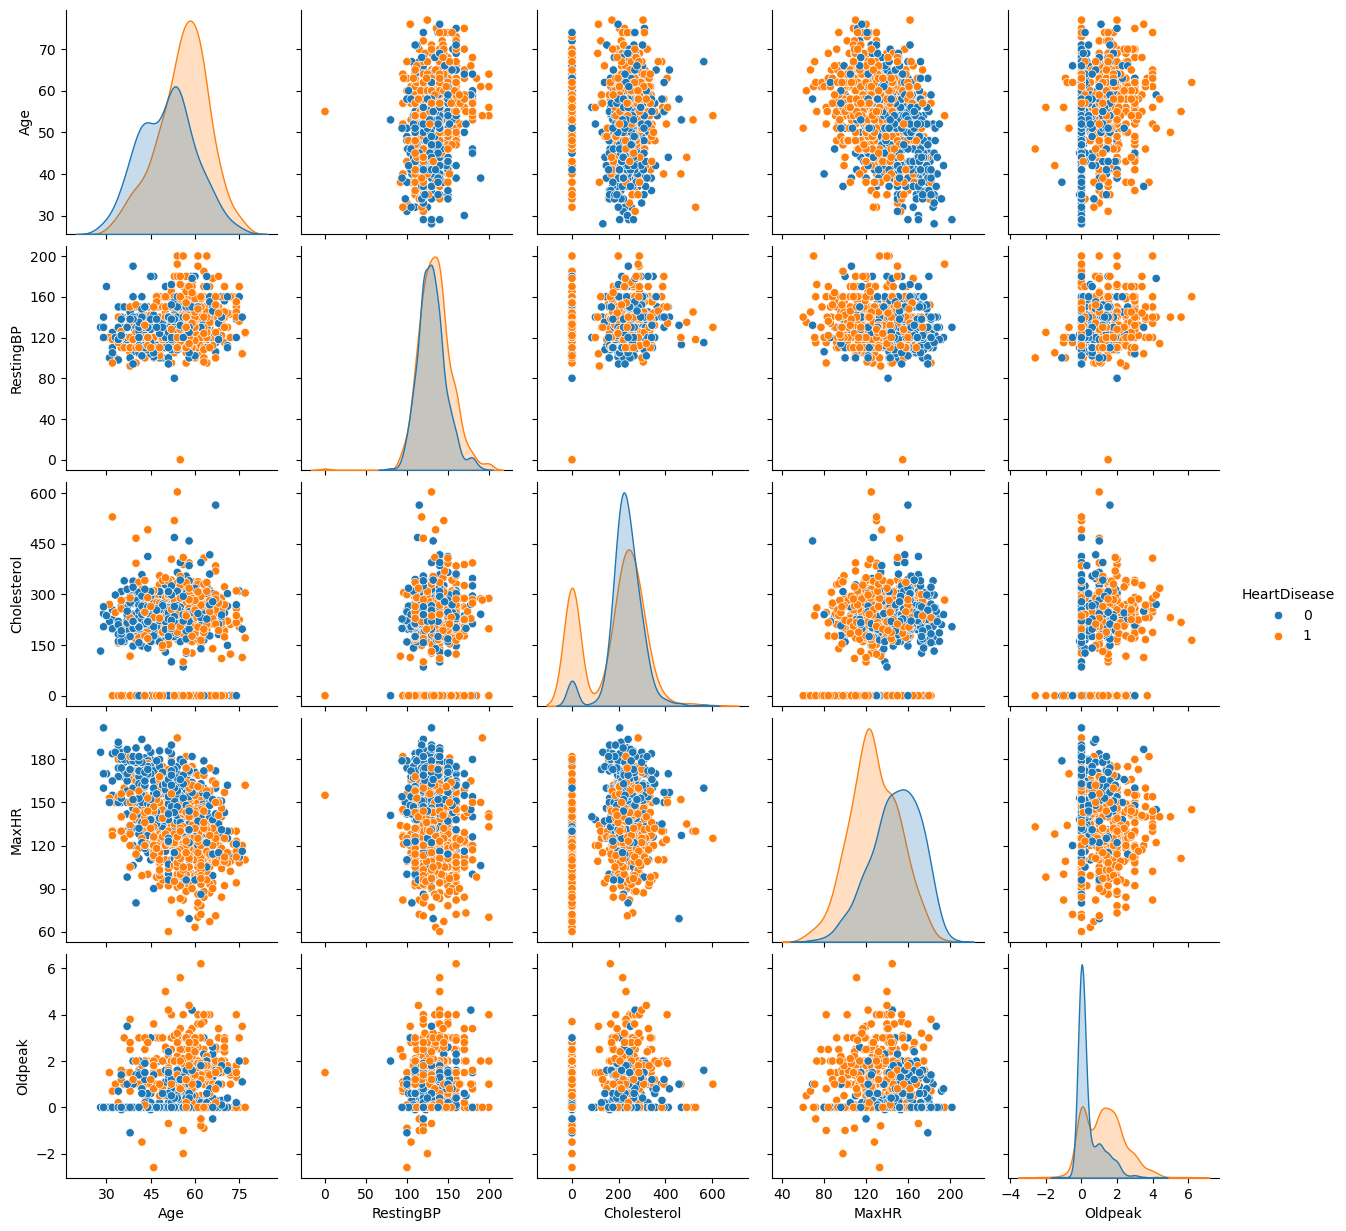

In [335]:

numeric_df = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']]

g = sns.pairplot(numeric_df, hue='HeartDisease')

for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))  
        ax.yaxis.set_major_locator(plt.MaxNLocator(6)) 

plt.show()

#### Pair plot interpretation 

* The following table illustrate potential relationships.

|Features | relationship type|
|:--:|:--:|
|Age X MaxHR| negative|
|Oldpeak X MaxHR|negative|

* There is not a clear class separation, however we could note the following observations:
    * The high values of the age tend to have higher number of heart disease, and the low values of the age tend to have higher a number of no-disease. However, there is an overlap between them, and the shift between the peaks (mean) 
    * Cases with no disease are concentrated around the zero Oldpeak value. As the Oldpeak values increase, the number of no-disease cases decreases. In addition, the overlap between disease and no-disease cases decreases, which increases the probability of distinguishing between the two classes when Oldpeak increases. This means that disease cases start to become more independent and separable at higher Oldpeak values.
    * The low values of MaxHR tend to have more heart disease cases, and the high values of MaxHR tend to have higher number of no-disease cases. However, there is an overlap around the MaxHR mean. Despite this overlap, the shift between the two distributions suggests that MaxHR is an informative feature that contributes to predicting the probability of heart disease, meaning that is has moderately linear corelation with the heart diseases.
    * There is a huge overlap between diseases and no diseases cases in the Cholesterol values, indicating a weak affect on the heart disease.
    * There is a huge overlap between diseases and no diseases cases in the RestingBP values, indicating a weak affect on the heart disease.

However, those observations are not conclusive.

### 2.5 Correlation Analysis (Heatmap Matrix)

While pairplots visually explore relationships and potential class separation between variables, the correlation heatmap quantitatively measures the strength and direction of linear associations between numerical features and the target variable. However, correlation analysis only reflects statistical association and does not necessarily imply causation; therefore, a strong correlation does not mean that a feature directly causes heart disease.

The positive value refers to a positive correlation and the opposite with the negative one.

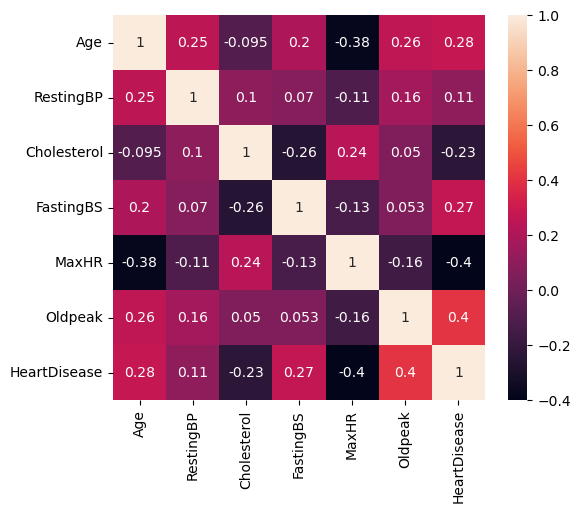

In [336]:
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

## **3. Data Preprocessing**

### 3.1 Handeling Zero Values

 #### 3.1.1 Cholesterol
 

In [337]:
display(f"Number of records with Cholesterol = 0 is {(df['Cholesterol'] == 0).sum()}")

'Number of records with Cholesterol = 0 is 172'

After identifying zero values in the Cholesterol feature during the visualization of the value distribution, these values were treated as missing data, since a cholesterol level of zero is not physiologically possible in humans. According to medical knowledge, normal total cholesterol levels in adults typically range between 125–200 mg/dL as mentiond above the the features table, meaning a value of zero most likely indicates missing or incorrectly recorded data rather than a true measurement.

A total of ***172 records*** contained zero values; therefore, removing them could lead to unnecessary data loss and potentially introduce bias into the dataset. Instead, these values were treated as missing data during preprocessing.


In [338]:
df['Cholesterol'].skew()

np.float64(-0.6100864307268192)


The distribution showes a skewness of −0.6, indicating a moderately left-skewed distribution. Since outliers were also observed in the visualization, the median will be used to impute missing values instead of the mean because it is less sensitive to extreme values.

In [339]:
preProcess_df = df.copy()

# replace 0 with NaN
preProcess_df['Cholesterol'] = preProcess_df['Cholesterol'].replace(0, np.nan)

# fill missing values with median
preProcess_df['Cholesterol'] = preProcess_df['Cholesterol'].fillna(preProcess_df['Cholesterol'].median())

chol_check = pd.DataFrame({
    "Cholesterol Check": ["Zero Values", "Missing (NaN)"],
    "Number of Patients": [
        (preProcess_df['Cholesterol'] == 0).sum(),
        preProcess_df['Cholesterol'].isna().sum()
    ]
})
chol_check

,Cholesterol Check,Number of Patients
0,Zero Values,0
1,Missing (NaN),0


 #### 3.1.2 RestingBP
 

In [340]:
display(f"Number of records with RestingBP = 0: {(df['RestingBP'] == 0).sum()}")

'Number of records with RestingBP = 0: 1'

One record in the RestingBP feature contained a value of zero. Since a resting blood pressure of zero is not physiologically possible, this record was considered invalid and therefore dropped from the dataset.

In [341]:
print("Before:", len(df))
preProcess_df = df[df['RestingBP'] != 0]

print("After:", len(preProcess_df))

Before: 918
After: 917


### 3.2 Discretization
discretization is the process of converting continuous numerical variables into discrete intervals or categories. It was not applied to most continuous variables to preserve numerical precision and the gradual nature of heart disease risk. However, cholesterol was discretized using established clinical thresholds, as heart disease risk is assessed based on the following risk categories:

#### Serum Cholesterol Categories

| Category | Total Cholesterol Level (mg/dL) |
|----------|----------------------------------|
| Desirable | < 200 |
| Borderline High | 200 – 239 |
| High | ≥ 240 |

**Reference:** [King Fahad Medical City – Cholesterol Levels Interpretation](https://www.kfmc.med.sa/EN/HealthEducation/StayHealthy/Pages/cholesterol-lipid-profile.aspx)

In [342]:
chol_bins = [0, 200, 240, np.inf]
chol_labels = ['Desirable', 'Borderline High', 'High']

preProcess_df['Chol_category'] = pd.cut(
    preProcess_df['Cholesterol'],
    bins=chol_bins,
    labels=chol_labels,
    right=False
) 

# Distribution of cholesterol categories in the dataset
chol_distribution = (
    preProcess_df['Chol_category']
    .value_counts()
    .rename_axis('Cholesterol Category')
    .reset_index(name='Number of Patients')
)

display(chol_distribution)

# Remove original cholesterol values to avoid redundant representation
preProcess_df.drop(columns=['Cholesterol'], inplace=True)

,Cholesterol Category,Number of Patients
0,High,363
1,Desirable,317
2,Borderline High,237


### 3.3 Encoding

To prepare categorical features for machine learning models, encoding techniques were applied depending on the type of variable.

In [343]:
# Show original categorical columns before encoding
print("Before Encoding:")
display(preProcess_df[['Sex', 'ExerciseAngina', 'ChestPainType', 'RestingECG', 'ST_Slope', 'Chol_category']].head())

Before Encoding:


,Sex,ExerciseAngina,ChestPainType,RestingECG,ST_Slope,Chol_category
0,M,N,ATA,Normal,Up,High
1,F,N,NAP,Normal,Flat,Desirable
2,M,N,ATA,ST,Up,High
3,F,Y,ASY,Normal,Flat,Borderline High
4,M,N,NAP,Normal,Up,Desirable


#### 3.3.1 Binary Encoding

Some categorical variables contain only two possible values. These variables were converted into binary numerical form (0/1), This binary representation preserves the information while allowing models to process the variables numerically.

The following variables were transformed:

- **Sex**: sex of the patient  
  - M → 1 (Male)  
  - F → 0 (Female)

- **ExerciseAngina**: exercise-induced angina  
  - Y → 1 (Yes)  
  - N → 0 (No)


In [344]:
preProcess_df['Sex'] = preProcess_df['Sex'].map({'M': 1, 'F': 0})
preProcess_df['ExerciseAngina'] = preProcess_df['ExerciseAngina'].map({'Y': 1, 'N': 0})

print("After Encoding:")
display(preProcess_df.head())

After Encoding:


,Age,Sex,ChestPainType,RestingBP,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Chol_category
0,40,1,ATA,140,0,Normal,172,0,0.0,Up,0,High
1,49,0,NAP,160,0,Normal,156,0,1.0,Flat,1,Desirable
2,37,1,ATA,130,0,ST,98,0,0.0,Up,0,High
3,48,0,ASY,138,0,Normal,108,1,1.5,Flat,1,Borderline High
4,54,1,NAP,150,0,Normal,122,0,0.0,Up,0,Desirable


#### 3.3.2 One-Hot Encoding

Categorical variables with more than two categories were encoded using **one-hot encoding**.
This method creates a column for every category preventing models from assuming any artificial ordering between categories, from each variable one category is removed and used as a reference (baseline). The remaining columns then show whether a sample belongs to a category compared to that reference category, which helps avoid redundancy in the data.

The following variables were one-hot encoded:

- **ChestPainType**  
  - TA: Typical Angina  
  - ATA: Atypical Angina  
  - NAP: Non-Anginal Pain  
  - ASY: Asymptomatic  

- **RestingECG**  
  - Normal: Normal ECG  
  - ST: ST-T wave abnormality  
  - LVH: Left ventricular hypertrophy  

- **ST_Slope**  
  - Up: Upsloping  
  - Flat: Flat  
  - Down: Downsloping 

- **Chol_category**  
  - Desirable
  - Borderline High
  - High  
  

In [345]:
categorical_cols = ['ChestPainType', 'RestingECG', 'ST_Slope', 'Chol_category']
preProcess_df = pd.get_dummies(preProcess_df, columns=categorical_cols, drop_first=True)

# convert True/False to 0/1
preProcess_df = preProcess_df.astype({col: 'int' for col in preProcess_df.select_dtypes('bool').columns})

print("After Encoding:")
display(preProcess_df.head())

After Encoding:


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Chol_category_Borderline High,Chol_category_High
0,40,1,140,0,172,0,0.0,0,1,0,0,1,0,0,1,0,1
1,49,0,160,0,156,0,1.0,1,0,1,0,1,0,1,0,0,0
2,37,1,130,0,98,0,0.0,0,1,0,0,0,1,0,1,0,1
3,48,0,138,0,108,1,1.5,1,0,0,0,1,0,1,0,1,0
4,54,1,150,0,122,0,0.0,0,0,1,0,1,0,0,1,0,0


After encoding the dataset still contains ***917 observations***, But the feature space expanded to ***17 variables***. This expansion may improve the model’s ability to capture patterns associated with heart disease, since each category can now contribute independently to the prediction. However, increasing the number of features can also slightly increase model complexity, and may introduce redundant information if features are highly correlated.

In [346]:
preProcess_df.shape

(917, 17)

### 3.4 Normalization

Normalization is the process of transforming continuous numerical features into a comparable scale. 
Without feature scaling, machine learning models may assign excessive importance to features with wider numerical ranges while underestimating features with smaller ranges.

Multiple normalization techniques can be applied depending on the feature data distribution as well as the presence of outliers. 
The following table summarizes the most wide normalization techniques and the situations in which each technique is most appropriate.

| Normalization Technique | Formula | Distribution Type | Outlier Sensitivity |
| :--- | :---: | :---: | :---: |
| Z-score Standardization | $x_{scaled}=\frac{x-\mu}{\sigma}$ | Approximately normal or symmetric distribution | Sensitive |
| Log Transformation | $x_{scaled}= \log(x)$ | Right-skewed distribution | Reduces effect of outliers  |
| RobustScaler | $x_{scaled}=\frac{x-\text{Median}(x)}{Q_{3}-Q_{1}}$ | Approximately normal or Moderate skew with outliers | Low sensitivity |
| Linear scaling| $x_{scaled}=\frac{x-x_{min}}{x_{max}-x_{min}}$| Approximately uniform distribution|Sensitive|

The feature distribution type can be visually assessed using histogram diagrams, while the existence of outliers can be identified through boxplot diagrams. 
However, visual inspection alone may be misleading; therefore, statistical measurements such as the skewness coefficient were also calculated using the `skew()` function to quantitatively evaluate distribution symmetry.
The following table illustrate the skewness coefficient ranges:

| Skewness coefficient range |Distribution Type |
| :--- | :---: |
|between -0.5 and 0.5 but not 0 |approximately normal|
|between -1 and -0.5 or between 0.5 and 1|moderately skewed|
|grater than 1 or less than -1 |highly skewed|


#### 3.4.1 Age Feature Normalization

Based on the previous Age histogram and boxplot diagrams:

- The histogram shows an approximately symmetric distribution.
- The boxplot shows no outliers.

To quantitatively prove the distribution type, we will calculate the skewness coefficient for the age feature.

In [347]:
print("The skewness coefficient of Age:", preProcess_df['Age'].skew())

The skewness coefficient of Age: -0.19532159788386802


The skewness coefficient of the age is within the approximately symmetric distribution range (-0.5 to 0.5).

Since there are no outliers and the distribution is approximately symmetric, the Z-score standardization was selected.


,Before Scaling,After Scaling
0,40,-1.432206
1,49,-0.478057
2,37,-1.750256
3,48,-0.584074
4,54,0.052026


Mean: 1.8596538340504257e-16
Std: 1.0005457026327034


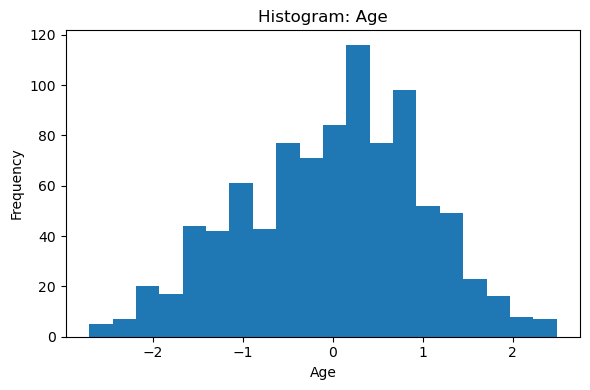

In [348]:
age_before=preProcess_df['Age']
scaler = StandardScaler()
preProcess_df['Age'] = scaler.fit_transform(preProcess_df[['Age']])

#prove the success of the normalization
age_comparison_table = pd.concat(
    [age_before.head(), preProcess_df['Age'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(age_comparison_table)

print("Mean:", preProcess_df['Age'].mean())
print("Std:", preProcess_df['Age'].std())

plt.figure(figsize=(6,4))
plt.hist(preProcess_df['Age'].dropna(), bins=20)
plt.title(f"Histogram: {'Age'}")
plt.xlabel('Age')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 3.4.2 RestingBP Feature Normalization 

Based on the previous RestingBP histogram and boxplot diagrams:

- The histogram shows a slightly right skewed distribution.
- The boxplot shows many outliers on the right, and few on the left.

To quantitatively prove the distribution type, we will calculate the skewness coefficient for the RestingBP feature.

In [349]:
print("The skewness coefficient of RestingBP:", preProcess_df['RestingBP'].skew())

The skewness coefficient of RestingBP: 0.6071947160162691


The skewness coefficient of the RestingBP is within the moderately right skewed range (0.5 to 1) 

The outliers might represent important clinically cases, removing them may result in the loss of important medical information. And since the skewness is not high (moderate skew), the RobustScaler was selected as an appropriate normalization technique.

,Before Scaling,After Scaling
0,140,0.5
1,160,1.5
2,130,0.0
3,138,0.4
4,150,1.0


Median: 0.0
Q1: -0.5
Q3: 0.5


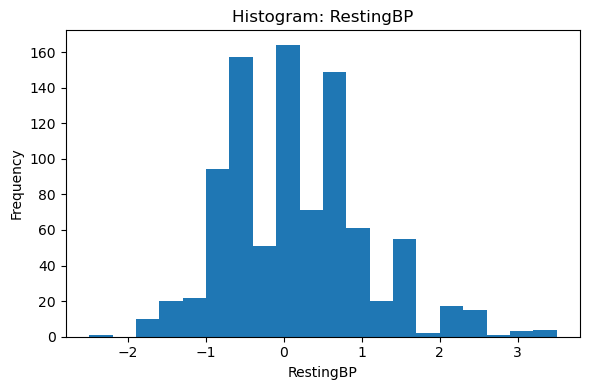

In [350]:
#create a copy of the original RestingBP values before normalization
RestingBP_before=preProcess_df['RestingBP'].copy()

#normalize RestingBP using RobustScaler
scaler = RobustScaler()
preProcess_df['RestingBP'] = scaler.fit_transform(preProcess_df[['RestingBP']])


#prove the success of the normalization 
RestingBP_comparison_table = pd.concat(
    [RestingBP_before.head(), preProcess_df['RestingBP'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(RestingBP_comparison_table)

print("Median:", preProcess_df['RestingBP'].median())
print("Q1:", preProcess_df['RestingBP'].quantile(0.25))
print("Q3:", preProcess_df['RestingBP'].quantile(0.75))

#visualize the distribution of RestingBP after normalization
plt.figure(figsize=(6,4))
plt.hist(preProcess_df['RestingBP'].dropna(), bins=20)
plt.title(f"Histogram: {'RestingBP'}")
plt.xlabel('RestingBP')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 3.4.3 MaxHR Feature Normalization

Based on the previous MaxHR histogram and boxplot diagrams:

* The histogram shows an approximately symmetric distribution.
* The boxplot shows few outliers on the left.

To quantitatively prove the distribution type, we will calculate the skewness coefficient for the MaxHR feature.

In [351]:
print("The skewness coefficient of MaxHR:", preProcess_df['MaxHR'].skew())

The skewness coefficient of MaxHR: -0.14245852926814553


The skewness coefficient of the MaxHR is within the approximately symmetric distribution range (-0.5 to 0.5).

The distribution is approximately symmetric and there are only few outliers that represent important clinically cases and cannot be deleted. And since those outliers are very few, they have insignificantly affect. Therefore, we selected the Z-score standardization.



,Before Scaling,After Scaling
0,172,1.383339
1,156,0.754736
2,98,-1.523953
3,108,-1.131075
4,122,-0.581047


Mean: -5.114048043638671e-16
Std: 1.0005457026327034


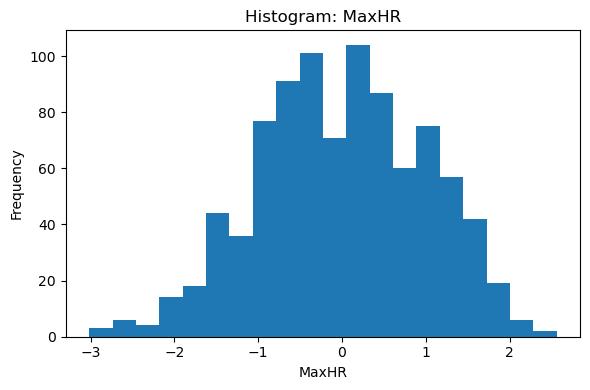

In [352]:
MaxHR_before=preProcess_df['MaxHR']
scaler = StandardScaler()
preProcess_df['MaxHR'] = scaler.fit_transform(preProcess_df[['MaxHR']])

#prove the success of the normalization
MaxHR_comparison_table = pd.concat(
    [MaxHR_before.head(), preProcess_df['MaxHR'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(MaxHR_comparison_table)

print("Mean:", preProcess_df['MaxHR'].mean())
print("Std:", preProcess_df['MaxHR'].std())

plt.figure(figsize=(6,4))
plt.hist(preProcess_df['MaxHR'].dropna(), bins=20)
plt.title(f"Histogram: {'MaxHR'}")
plt.xlabel('MaxHR')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 3.4.4 Oldpeak Feature Normalization 

Based on the previous Oldpeak histogram and boxplot diagrams:

- The histogram shows a right skewness.
- The boxplot shows a many outliers on the right, while only a few outliers appear on the left.

To quantitatively prove the distribution type, we will calculate the skewness coefficient for the Oldpeak feature.

In [353]:
print("The skewness coefficient of Oldpeak:", preProcess_df['Oldpeak'].skew())

The skewness coefficient of Oldpeak: 1.024544634289045


The skewness coefficient of the Oldpeak feature is approximately 1, indicating a right-skewed distribution.

The feature contains several outliers, and both the histogram and the skewness coefficient suggest a noticeable right skew. However, these outliers are medically valid and may represent important clinical cases so we can not remove them.Therefore, The appropriate technique may be the log transformation followed by RobustScaler. but the presence of negative values requires shifting the data before applying the log transformation which leads to increase the impact of the log transformation, since the log transformation compresses larger values more than smaller ones, which can reduce the differences between observations.

And since the value of the skewness coefficient is 1.0228720218107528 which closer to the moderate rather than severe skewness, we selected the RobustScaler technique because it is less sensitive to outliers.



,Before Scaling,After Scaling
0,0.0,-0.400000
1,1.0,0.266667
2,0.0,-0.400000
3,1.5,0.600000
4,0.0,-0.400000


Median: 0.0
Q1: -0.39999999999999997
Q3: 0.6


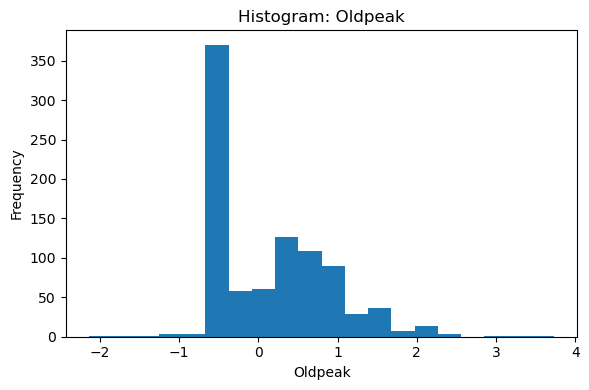

In [354]:
Oldpeak_before=preProcess_df['Oldpeak'].copy()

scaler = RobustScaler()

preProcess_df['Oldpeak'] = scaler.fit_transform(preProcess_df[['Oldpeak']])


#prove the success of the normalization 
Oldpeak_comparison_table = pd.concat(
    [Oldpeak_before.head(), preProcess_df['Oldpeak'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(Oldpeak_comparison_table)

print("Median:", preProcess_df['Oldpeak'].median())
print("Q1:", preProcess_df['Oldpeak'].quantile(0.25))
print("Q3:", preProcess_df['Oldpeak'].quantile(0.75))

plt.figure(figsize=(6,4))
plt.hist(preProcess_df['Oldpeak'].dropna(), bins=20)
plt.title(f"Histogram: {'Oldpeak'}")
plt.xlabel('Oldpeak')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

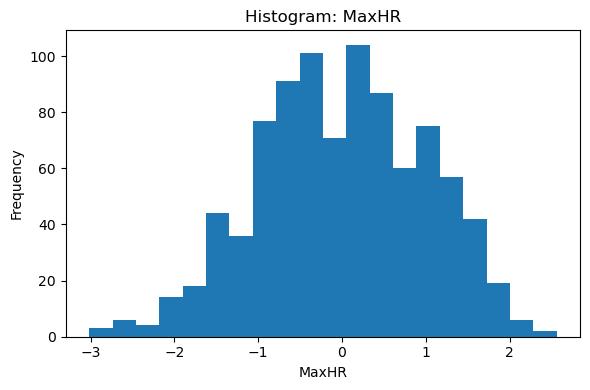

In [355]:
plt.figure(figsize=(6,4))
plt.hist(preProcess_df['MaxHR'].dropna(), bins=20)
plt.title(f"Histogram: {'MaxHR'}")
plt.xlabel('MaxHR')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 3.5 Variable Removal
No variables were removed during preprocessing, as all features were clinically relevant and no variables exhibited constant values or excessive missing data. Removing variables without proper statistical or medical justification could result in unnecessary information loss and reduced predictive performance.

## Preprocessed Dataset Ready for Modeling

After completing the preprocessing steps, the dataset is now cleaned and transformed into a format suitable for machine learning models. Missing or invalid values were handled, categorical variables were encoded, and numerical features were normalized to ensure consistent scales across variables.

The resulting dataset contains the processed feature set that will be used in the next phase for training supervised machine learning models.

## Key Insights and Challenges

During the exploratory data analysis, several important observations were identified. Some features showed noticeable relationships with the target variable, suggesting that they may play an important role in predicting heart disease.

The visualizations also helped identify potential issues such as skewed distributions and invalid values. These issues were addressed during the preprocessing stage to improve the quality of the dataset.

One of the main challenges encountered was handling medically unrealistic values and ensuring that preprocessing steps preserved meaningful clinical information while preparing the data for machine learning models.

These insights will help guide the selection and evaluation of supervised learning models in the next phase of the project.